  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   

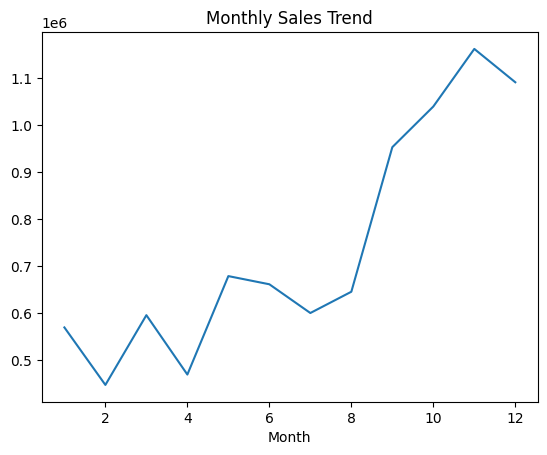

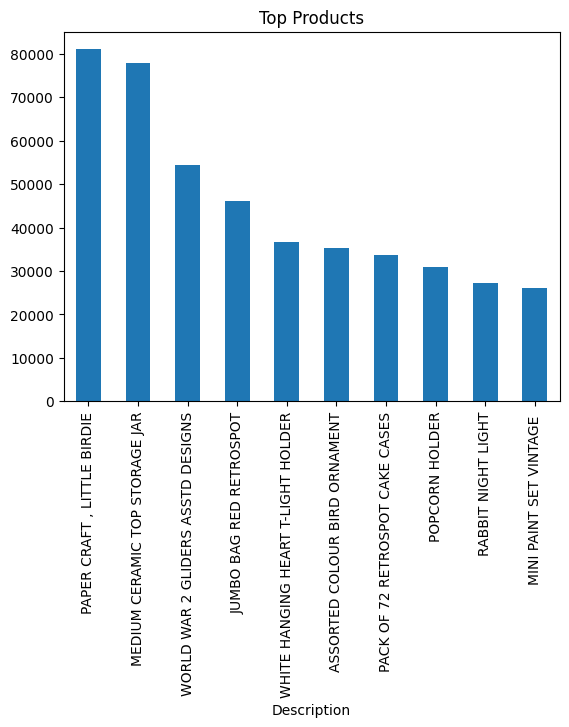


 ✅ File saved successfully!


In [ ]:
import pandas as pd

df = pd.read_csv("OnlineRetail.csv", encoding='ISO-8859-1')
print(df.head())

print(df.shape)
print(df.info())
print(df.isnull().sum())

# Data Cleaning
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
#df.head()

#Create Important Columns
# Total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Month
df['Month'] = df['InvoiceDate'].dt.month
print("\n")
df.head()

# SALES ANALYSIS

# 1: Total Revenue
total_revenue = df['TotalPrice'].sum()
print("\n")
print("Total Revenue:", total_revenue)

# 2: Monthly Sales Trend
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
print("\n")
print(monthly_sales)

# 3: Sales by Country
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
print("\n")
print(country_sales.head(10))

# CUSTOMER ANALYSIS

# 1 : Top Customers
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print("\n")
print(top_customers)

# 2 : Customer Segmentation (Basic)
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum()

# High / Medium / Low
labels = ['Low','Medium','High']
df_seg = pd.cut(customer_spending, bins=3, labels=labels)
print("\n")
print(df_seg.value_counts())

# PRODUCT ANALYSIS - Top Products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("\n")
print(top_products)

# VISUALIZATION
import matplotlib.pyplot as plt

# Monthly trend
print("\n")
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

# Top products
print("\n")
top_products.plot(kind='bar')
plt.title("Top Products")
plt.xticks(rotation=90)
plt.show()


# Save file

df.to_csv("Online_Retail_data.csv", index=False)
print("\n ✅ File saved successfully!")

